# Multiple Linear Regression

In this stage we will perform a multiple linear regression analysis in order to predict a movie's fan rating based on all the information we have about the movie.  We will use the `statsmodels` approach, both with and without considering an intercept.

## Import libraries

The next code is for all the libraries that we'll use in the document

In [1]:
# Data wrangling
# ==============================================================================
import pandas as pd
import numpy as np

In [2]:
# Plots
# ==============================================================================
import matplotlib.pyplot as plt
#from matplotlib import style
import seaborn as sns

In [3]:
# Preprocessing and modeling
# ==============================================================================
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from scipy import stats

In [4]:
# Configuring matplotlib and seaborn
# ==========================================================================bb====
from matplotlib.colors import ListedColormap
plt.rcParams['savefig.bbox'] = "tight"
sns.set_style('whitegrid') # or plt.style.use('ggplot')
sns.set_palette('viridis')

In [5]:
# For a list of colormaps uncomment the following lines
#from matplotlib import colormaps
#sorted(list(colormaps))

In [6]:
# Configuring warnings
# ==============================================================================
# If you want to suppress warnings uncomment the following lines
#import warnings
#warnings.filterwarnings('ignore')

## Loading the dataset

We load here our clean and final dataset

In [7]:
movies = pd.read_csv('Team6_final.csv', index_col='Title')

We are going to predict the rating of a movie based on the data base that we have, we are going to use `Personal` as our predicted variable and the other variables (numerical) are ging to be the predictors.

First we'll calculate the mean of our predicted variable, later we're going to use it.

In [8]:
mean_predicted_variable = movies['Personal'].mean()
mean_predicted_variable

np.float64(84.03726708074534)

We'll convert `Year` column to a categorical variable (`str`) because we're not going to need it as a predictor.

In [9]:
movies['Year']=movies['Year'].astype(int).astype(str)

In [10]:
movies.describe()

,Runtime,Budget,Revenue,Personal,IMDb,Rotten_Tomatoes,Metacritic,Filmaffinity,Fans
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000
mean,124.509317,57.236440,309.491286,84.037267,79.658385,88.937888,79.180124,78.863354,70.734648
std,21.472982,59.456142,293.844656,10.692222,4.718455,7.826788,10.488022,10.509220,6.178755
min,81.000000,1.000000,4.100000,50.000000,68.000000,63.000000,55.000000,55.000000,55.562500
25%,109.000000,14.000000,76.200000,78.000000,77.000000,85.000000,71.000000,71.000000,66.187500
50%,121.000000,30.000000,217.000000,87.000000,80.000000,91.000000,80.000000,79.000000,71.100000
75%,138.000000,90.000000,436.200000,91.000000,83.000000,94.000000,87.000000,88.000000,75.105263
max,180.000000,250.000000,1140.000000,100.000000,94.000000,100.000000,100.000000,98.000000,85.066667


We can see that `Year` column no longer appears so that's good.

## Relations between variables

Next, we're going to be identifying which are the best predictors for the model, and detect correlations between the predictors.

In [11]:
# Correlation between numerical columns
# ==============================================================================
corr_matrix = movies.select_dtypes(include=['float64', 'int']).corr(method='pearson')

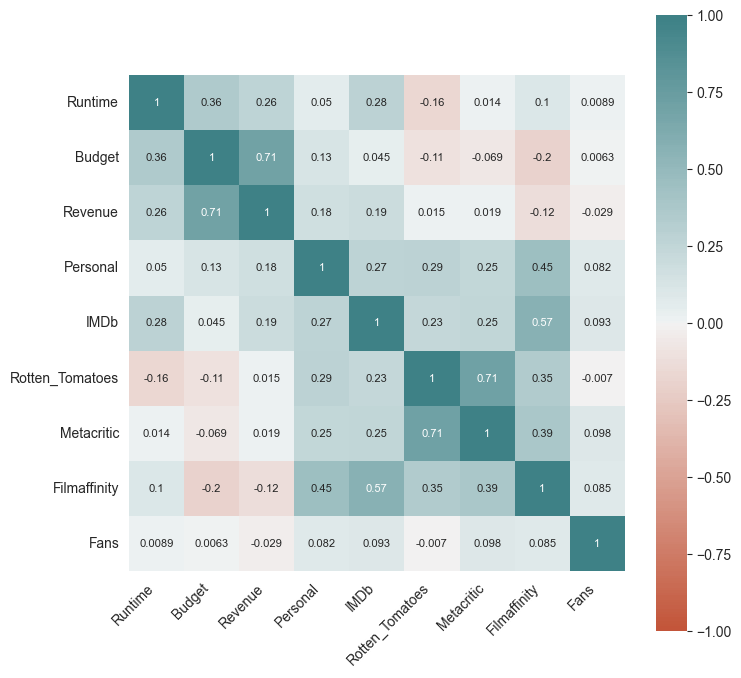

In [12]:
# Heatmap for correlation matrix
# ==============================================================================
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 8))

sns.heatmap(
    corr_matrix,
    annot     = True,
    cbar      = True,
    annot_kws = {"size": 8},
    vmin      = -1,
    vmax      = 1,
    center    = 0,
    cmap      = sns.diverging_palette(20, 200, n=200),
    square    = True,
    ax        = ax
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation = 45,
    horizontalalignment = 'right',
)

ax.tick_params(labelsize = 10)

Okey we have the heat map, but theres too many information and we only need  the highest correlated variables so we will display a heatmap that only shows where the correlationis greater than 60%.

In [13]:
high_corr_matrix = corr_matrix[abs(corr_matrix) > 0.6]

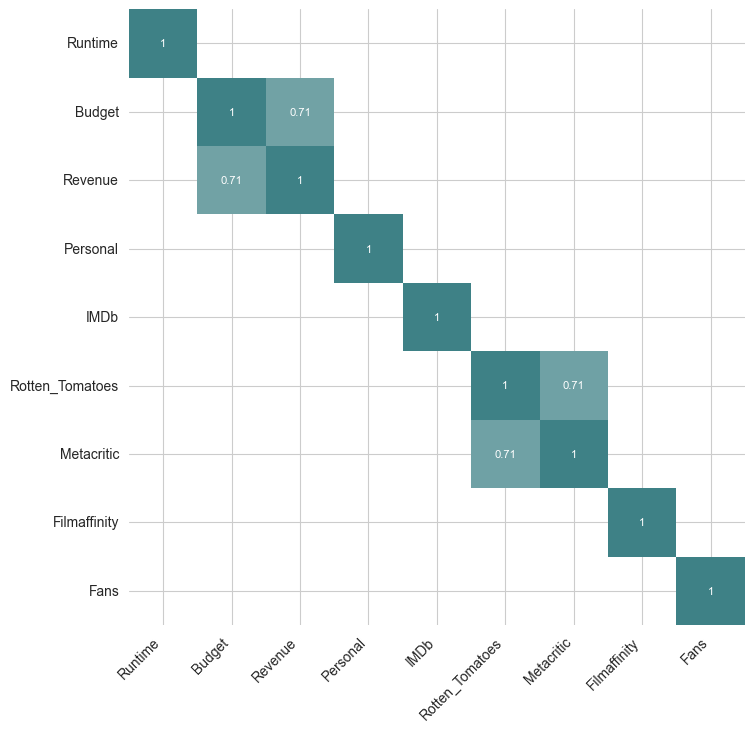

In [14]:
# Heatmap for correlation matrix - large values
# ==============================================================================
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 8))

sns.heatmap(
    high_corr_matrix,
    annot     = True,
    cbar      = False,
    annot_kws = {"size": 8},
    vmin      = -1,
    vmax      = 1,
    center    = 0,
    cmap      = sns.diverging_palette(20, 200, n=200),
    square    = True,
    ax        = ax
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation = 45,
    horizontalalignment = 'right',
)

ax.tick_params(labelsize = 10)

Observations: `Metacritic` and `Rotten_Tomatoes` have a high correlation of 0.71 and the same for `Budget` and `Revenue`, hinting that maybe after fitting our model we'll eliminate some of these variables because of therir high correlation.

Next is the correlation between our predicted variable with all the other predictors.

In [15]:
Personal_corr_matrix = corr_matrix[['Personal']].transpose()

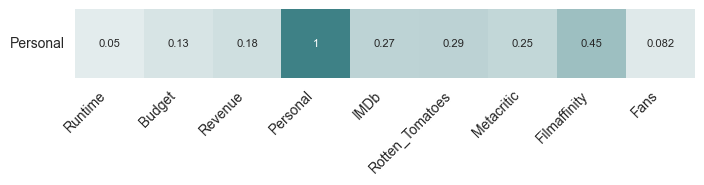

In [16]:
# Heatmap for correlation matrix - large values
# ==============================================================================
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 8))

sns.heatmap(
    Personal_corr_matrix,
    annot     = True,
    cbar      = False,
    annot_kws = {"size": 8},
    vmin      = -1,
    vmax      = 1,
    center    = 0,
    cmap      = sns.diverging_palette(20, 200, n=200),
    square    = True,
    ax        = ax
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation = 45,
    horizontalalignment = 'right'
)
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation = 0,
    horizontalalignment = 'right'
)

ax.tick_params(labelsize = 10)

Observations: `Personal` has the lowest correlation with `Runtime`, meaning that, that variable is not important, and its proabble that we eliminate it from the model. Also `Personal` has a high correlation with `Filmaffinity`.

## Distribution of numerical variables

Now, we show a histogram and distribution plot for each of our numerical variables.

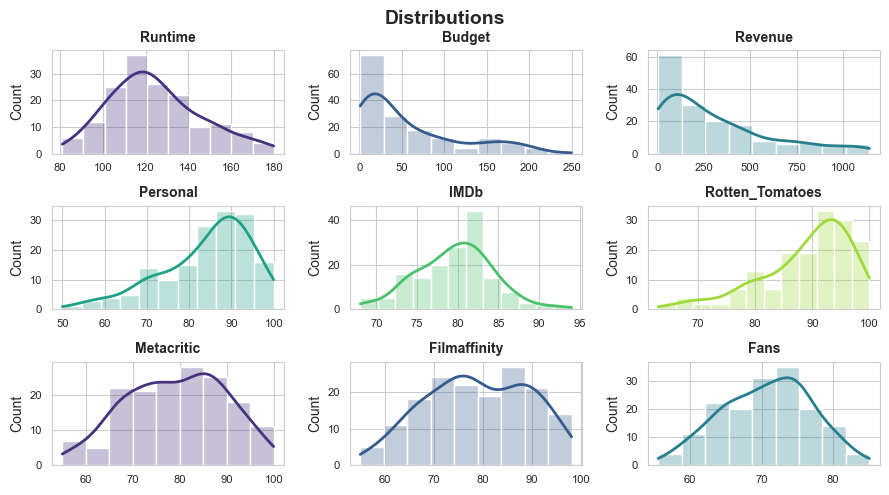

In [17]:
# Distribution plots for each numerical variable
# ==============================================================================
# 
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(9, 5))
axes = axes.flat
columnas_numeric = movies.select_dtypes(include=['float64', 'int']).columns

for i, colum in enumerate(columnas_numeric):
    sns.histplot(
        data    = movies,
        x       = colum,
        stat    = 'count',
        kde     = True,
        color   = (list(plt.rcParams['axes.prop_cycle'])*2)[i]["color"],
        line_kws= {'linewidth': 2},
        alpha   = 0.3,
        ax      = axes[i]
    )
    axes[i].set_title(colum, fontsize = 10, fontweight = "bold")
    axes[i].tick_params(labelsize = 8)
    axes[i].set_xlabel("")


    
fig.tight_layout()
plt.subplots_adjust(top = 0.9)
fig.suptitle('Distributions', fontsize = 14, fontweight = "bold");

We can observe that `Personal` graph has a similar distribution with the `Rotten_Tomatoes` graph, so probably it will be the best predictor, but maybe it isn't.

## Fitting the model

We will use **Statsmodels** for fitting the linear regression model, presenting all variants of the process as we did with simple linear regression.

### Setting up the data for training and testing the model

In [18]:
# Train-test Splitting
# ==============================================================================
X = movies.select_dtypes(include=['float64', 'int'])
model_columns = X.columns
X.drop(['Personal'], axis = 1, inplace=True)
y = movies['Personal']

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y.values.reshape(-1,1),
                                        train_size   = 0.8,
                                        random_state = 1234,
                                        shuffle      = True
                                    )

In [19]:
data_train = pd.DataFrame(
                   np.hstack((X_train, y_train)),
                   columns=model_columns
              )

In [20]:
model_columns

Index(['Runtime', 'Budget', 'Revenue', 'Personal', 'IMDb', 'Rotten_Tomatoes',
       'Metacritic', 'Filmaffinity', 'Fans'],
      dtype='object')

### Model fitting with a formula

In [21]:

model = smf.ols(formula = 'Personal ~ Runtime + Budget + Revenue + Fans + IMDb + Rotten_Tomatoes\
        + Metacritic + Filmaffinity', data = data_train)
model = model.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Personal   R-squared:                       0.498
Model:                            OLS   Adj. R-squared:                  0.464
Method:                 Least Squares   F-statistic:                     14.73
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           8.23e-15
Time:                        11:48:02   Log-Likelihood:                -333.41
No. Observations:                 128   AIC:                             684.8
Df Residuals:                     119   BIC:                             710.5
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          43.9979      5.616      7.835      0.000      32.878      55.118
Runtime             0.0421      0.015      2.743      0.007       0.012       0.072
Budget             -0.0174      0.007     -2.371      0.019      -0.032      -0.003
Revenue             0.0057      0.001      3.945      0.000       0.003       0.009
Fans               -0.0417      0.034     -1.245      0.216      -0.108       0.025
IMDb                0.0961      0.060      1.607      0.111      -0.022       0.214
Rotten_Tomatoes    -0.0170      0.045     -0.380      0.704      -0.106       0.072
Metacritic          0.2439      0.037      6.669      0.000       0.171       0.316
Filmaffinity        0.0944      0.049      1.912      0.058      -0.003       0.192
==============================================================================
Omnibus:                        0.329   Durbin-Watson:                   1.680
Prob(Omnibus):                  0.848   Jarque-Bera (JB):                0.351
Skew:                           0.118   Prob(JB):                        0.839
Kurtosis:                       2.901   Cond. No.                     8.87e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.87e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Our model has an $R^2$ value (0.464), and this can explain 46.4% of the observed Personal variability. The p-value for the model is highly significant (8.23e-15), so we can accept the hypothesis that our model is better than what would be expected of random chance. We also notice that `Rotten_Tomatoes` has the highest *$p$-value*' of 0.704.

### Eliminating variables that have no significant predictive power

We'll eliminate *$p$-value*'s that are higher than 0.05 or 5%, because these aren't really important for the construction of the model. Also we're going to eliminate one at a time to view the changes, if any variable that was higher than 5% becomes lower than 5% after removing variables then we keep it.

The first variable we're going to remove is  `Rotten_Tomatoes` that has the highest *$p$-value*' of 0.704.

In [22]:
model = smf.ols(formula = 'Personal ~ Runtime + Budget + Revenue + Fans + IMDb\
        + Metacritic + Filmaffinity', data = data_train)
model = model.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Personal   R-squared:                       0.497
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     16.94
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           2.04e-15
Time:                        11:48:02   Log-Likelihood:                -333.49
No. Observations:                 128   AIC:                             683.0
Df Residuals:                     120   BIC:                             705.8
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       44.4731      5.455      8.152      0.000      33.672      55.274
Runtime          0.0415      0.015      2.730      0.007       0.011       0.072
Budget          -0.0172      0.007     -2.363      0.020      -0.032      -0.003
Revenue          0.0056      0.001      3.941      0.000       0.003       0.008
Fans            -0.0409      0.033     -1.227      0.222      -0.107       0.025
IMDb             0.0812      0.045      1.800      0.074      -0.008       0.171
Metacritic       0.2399      0.035      6.867      0.000       0.171       0.309
Filmaffinity     0.0916      0.049      1.883      0.062      -0.005       0.188
==============================================================================
Omnibus:                        0.213   Durbin-Watson:                   1.678
Prob(Omnibus):                  0.899   Jarque-Bera (JB):                0.190
Skew:                           0.090   Prob(JB):                        0.909
Kurtosis:                       2.944   Cond. No.                     8.57e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.57e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Observations: `Omnibus` decreased to 0.213 and `Cond. No.` decreased to 8.57e+03, also the $p$-value of predictors Fillmaffinity and Fans increased, the rest or predictors decreased.

Now we're going to remove is  `Fans` that has the highest *$p$-value*' of 0.222.

In [23]:
model = smf.ols(formula = 'Personal ~ Runtime + Budget + Revenue + IMDb + Metacritic + Filmaffinity', data = data_train)
model = model.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Personal   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.465
Method:                 Least Squares   F-statistic:                     19.43
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           9.01e-16
Time:                        11:48:02   Log-Likelihood:                -334.29
No. Observations:                 128   AIC:                             682.6
Df Residuals:                     121   BIC:                             702.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       43.2244      5.371      8.048      0.000      32.592      53.857
Runtime          0.0429      0.015      2.819      0.006       0.013       0.073
Budget          -0.0181      0.007     -2.481      0.014      -0.032      -0.004
Revenue          0.0054      0.001      3.800      0.000       0.003       0.008
IMDb             0.0736      0.045      1.642      0.103      -0.015       0.162
Metacritic       0.2248      0.033      6.863      0.000       0.160       0.290
Filmaffinity     0.0862      0.049      1.776      0.078      -0.010       0.182
==============================================================================
Omnibus:                        0.314   Durbin-Watson:                   1.687
Prob(Omnibus):                  0.855   Jarque-Bera (JB):                0.476
Skew:                           0.076   Prob(JB):                        0.788
Kurtosis:                       2.743   Cond. No.                     8.32e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.32e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Now we're going to remove is  `IMDb` that has the highest *$p$-value*' of 0.103.

In [24]:
model = smf.ols(formula = 'Personal ~ Runtime + Budget + Revenue + Metacritic + Filmaffinity', data = data_train)
model = model.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Personal   R-squared:                       0.479
Model:                            OLS   Adj. R-squared:                  0.458
Method:                 Least Squares   F-statistic:                     22.46
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           6.49e-16
Time:                        11:48:02   Log-Likelihood:                -335.70
No. Observations:                 128   AIC:                             683.4
Df Residuals:                     122   BIC:                             700.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       48.8291      4.176     11.694      0.000      40.563      57.095
Runtime          0.0357      0.015      2.432      0.016       0.007       0.065
Budget          -0.0185      0.007     -2.531      0.013      -0.033      -0.004
Revenue          0.0057      0.001      3.996      0.000       0.003       0.008
Metacritic       0.2486      0.030      8.402      0.000       0.190       0.307
Filmaffinity     0.0849      0.049      1.738      0.085      -0.012       0.182
==============================================================================
Omnibus:                        0.015   Durbin-Watson:                   1.738
Prob(Omnibus):                  0.992   Jarque-Bera (JB):                0.130
Skew:                           0.005   Prob(JB):                        0.937
Kurtosis:                       2.844   Cond. No.                     6.35e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.35e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Now we're going to remove is  `Filmaffinity` that has the highest *$p$-value* of 0.085. Which even after having the best correlation with Personal, the *$p$-value* kept increasing.

In [25]:
model = smf.ols(formula = 'Personal ~ Runtime + Budget + Revenue + Metacritic', data = data_train)
model = model.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Personal   R-squared:                       0.466
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     26.88
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           4.97e-16
Time:                        11:48:02   Log-Likelihood:                -337.27
No. Observations:                 128   AIC:                             684.5
Df Residuals:                     123   BIC:                             698.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     54.3681      2.720     19.988      0.000      48.984      59.752
Runtime        0.0355      0.015      2.401      0.018       0.006       0.065
Budget        -0.0175      0.007     -2.373      0.019      -0.032      -0.003
Revenue        0.0055      0.001      3.839      0.000       0.003       0.008
Metacritic     0.2549      0.030      8.610      0.000       0.196       0.313
==============================================================================
Omnibus:                        0.255   Durbin-Watson:                   1.737
Prob(Omnibus):                  0.881   Jarque-Bera (JB):                0.427
Skew:                           0.020   Prob(JB):                        0.808
Kurtosis:                       2.720   Cond. No.                     4.07e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.07e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The $p$-value of all the predictors now are lower than 0.05 so we can begin working with this model formula

### Confidence intervals for the coefficients

Now that we've obtained our most significant model, we'll explore the confidence intervals for the coefficients.

In [26]:
# Confidence intervals for the coefficients
# ==============================================================================
intervals_ci = model.conf_int(alpha=0.05)
intervals_ci.columns = ['2.5%', '97.5%']
intervals_ci

,2.5%,97.5%
Intercept,48.983963,59.752138
Runtime,0.006230,0.064762
Budget,-0.032035,-0.002896
Revenue,0.002657,0.008312
Metacritic,0.196269,0.313462


We can say that all of the variables are statistically significant predictors of the target variable. Also we can notice that Budget has a negative impact meaning that higher budget movies predict a lower score.

## Residual analysis

We perform a basic residual analysis. In order for the model to be adequate, the sum of residues must be close to zero.

In [27]:
# Residual analysis
# ==============================================================================
y_train = y_train.flatten()
prediction_train = model.predict(exog = X_train)
residues_train   = prediction_train - y_train

In [28]:
residues_train.sum()

np.float64(-622.3577041327429)

The result of the sum is -622.3577041327405 which tells us that the residues are skewed to the left and that our model is not adequate. So now we do a graphical residual analysis to see if the conditions of homoscedasticity and normality of the residues is satisfied.

### Graphs

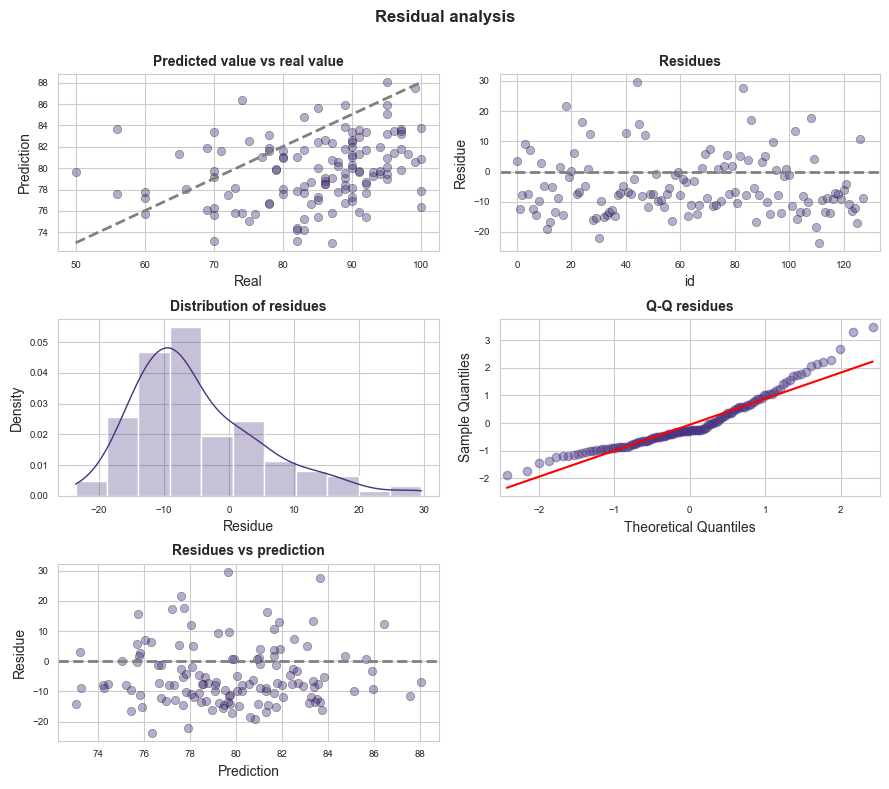

In [49]:
# Graphs
# ==============================================================================
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(9, 8))

# axes[0,0]
sns.scatterplot(
    x          = y_train,
    y          = prediction_train,
    edgecolors = (0, 0, 0),
    alpha      = 0.4,
    ax         = axes[0, 0]
)

points = [(y_train.min(),prediction_train.min()), (y_train.max(), prediction_train.max())]  # x, y coordinates
line_data = pd.DataFrame(points, columns=['x', 'y'])
sns.lineplot(
    x          = 'x',
    y          = 'y',
    data       = line_data, 
    linestyle  = '--', 
    color      = 'gray', 
    lw         = 2,
    ax         = axes[0, 0]
)

axes[0, 0].set_title('Predicted value vs real value', fontsize = 10, fontweight = "bold")
axes[0, 0].set_xlabel('Real')
axes[0, 0].set_ylabel('Prediction')
axes[0, 0].tick_params(labelsize = 7)

# axes[0,1]
sns.scatterplot(
    x          = list(range(len(y_train))),
    y          = residues_train,
    edgecolors = (0, 0, 0),
    alpha      = 0.4,
    ax         = axes[0, 1]
)

axes[0, 1].axhline(y = 0, linestyle = '--', color = 'gray', lw=2)
axes[0, 1].set_title('Residues', fontsize = 10, fontweight = "bold")
axes[0, 1].set_xlabel('id')
axes[0, 1].set_ylabel('Residue')
axes[0, 1].tick_params(labelsize = 7)

# axes[1, 0]
sns.histplot(
    data    = residues_train,
    stat    = "density",
    kde     = True,
    line_kws= {'linewidth': 1},
    alpha   = 0.3,
    ax      = axes[1, 0]
)

axes[1, 0].set_title('Distribution of residues', fontsize = 10,
                     fontweight = "bold")
axes[1, 0].set_xlabel("Residue")
axes[1, 0].tick_params(labelsize = 7)

# axes[1, 1]
sm.qqplot(
    residues_train,
    fit   = True,
    line  = 'q',
    ax    = axes[1, 1], 
    alpha = 0.4,
    lw    = 2
)

axes[1, 1].set_title('Q-Q residues', fontsize = 10, fontweight = "bold")
axes[1, 1].tick_params(labelsize = 7)

# axes[2, 0]
sns.scatterplot(
    x          = prediction_train, 
    y          = residues_train,
    edgecolors = (0, 0, 0),
    alpha      = 0.4,
    ax         = axes[2, 0]
)

axes[2, 0].axhline(y = 0, linestyle = '--', color = 'grey', lw=2)
axes[2, 0].set_title('Residues vs prediction', fontsize = 10, fontweight = "bold")
axes[2, 0].set_xlabel('Prediction')
axes[2, 0].set_ylabel('Residue')
axes[2, 0].tick_params(labelsize = 7)

# Eliminate empty axes
fig.delaxes(axes[2,1])

fig.tight_layout()
plt.subplots_adjust(top=0.9)
fig.suptitle('Residual analysis', fontsize = 12, fontweight = "bold");

Observations:
-We can say that the Homoscedasticity is satisfied because the model's errors are equally spread across all predictions.
-Linearity is not satisfied because model systematically underpredicts scores.

### Normality test

For the Normality test we're going to use the *Shapiro-Wilk test* and *D'Agostino's K-squared test*. In both tests if the *$p$-value* is smaller than the significance level *alpha* then the data is not normally distributed.

In [30]:
# Shapiro-Wilk test
# ==============================================================================
shapiro_test = stats.shapiro(residues_train)
shapiro_test

ShapiroResult(statistic=np.float64(0.9244180447637173), pvalue=np.float64(2.285009598102131e-06))

In [31]:
# D'Agostino's K-squared test
# ==============================================================================
k2, p_value = stats.normaltest(residues_train)
print(f"Statistic= {k2}, p-value = {p_value}")

Statistic= 24.346452457215143, p-value = 5.166959077788958e-06


We can see that both tests prove that the data is not normally distributed because the *$p$-value*'s< 0.05.

## Predictions

Now that we have trained our model, we can obtain predictions for new data. Models from **statsmodels** allow us to calculate confidence intervals associated with each prediction.

In [32]:
# # Predictions with 95% confidence intervals
# ==============================================================================
predictions = model.get_prediction(exog = X_train).summary_frame(alpha=0.05)
predictions.head(4)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,81.630875,0.715160,80.215260,83.046489,74.673361,88.588388
1,83.506480,0.646766,82.226247,84.786713,76.575245,90.437715
2,75.227296,0.700319,73.841058,76.613535,68.275701,82.178892
3,79.223090,0.436205,78.359650,80.086530,72.356610,86.089570


## Model error test

Perhaps one of the best indicators that our model is valid and can be used reliably is the root mean square error (`rmse`) of the residues. As a rule of thumb, the `rmse` should be less than 10% of the mean of the predicted variable.

In [33]:
# Model error test
# ==============================================================================
predictions = model.predict(exog = X_test)
rmse = root_mean_squared_error(
        y_true  = y_test,
        y_pred  = predictions
       )
print("")
print(f"The test error (rmse) is: {rmse}, which is {rmse/mean_predicted_variable*100:.2f}% of the mean of `Personal`.")


The test error (rmse) is: 11.468692353633358, which is 13.65% of the mean of `Personal`.


In [34]:
residues=y_test[:,0]-predictions
residues.sum()

np.float64(81.48432836306793)

In [35]:
model.params

Intercept     54.368051
Runtime        0.035496
Budget        -0.017466
Revenue        0.005484
Metacritic     0.254866
dtype: float64

## Interpretating our results

The multiple linear regression that we obtained,

$$Personal = 54.368051 + 0.035496\,Runtime - 0.017466\,Budget + 0.005484\,Revenue + 0.254866\,Metacritic 

The model achieved an $R\text{-squared}$ value of $0.466$, which indicates that our set of predictor variables ($\text{Runtime}$, $\text{Budget}$, $\text{Revenue}$, and $\text{Metacritic}$) explains $46.6\%$ of the observed variation in the $\text{Personal}$ score. The adjusted $R\text{-squared}$ is $0.449$. The overall model is statistically significant, as confirmed by the highly significant $\text{F}$-statistic ($\text{Prob}(\text{F-statistic}): 4.97e\text{-}16$). This low $\text{p-value}$ provides strong evidence that the model's explanatory power is not due to random chance.

Normality is not satisfied (p-values for Shapiro-Wilk and D'Agostino's K-squared are  < 0.05 ). Because the residuals are not normally distributed, the estimated confidence intervals for the coefficients are not importan.

The model error test is 11.47, so the model predictions get farther from the real value by 11.47 **on average**.

## Interaction between predictors

Recall that a two-predictor linear model follows the equation

$$y=\beta_0+\beta_1 x_1+\beta_2 x_2+\varepsilon$$
 
According to this definition, an increase of one unit of the predictor $x_1$ produces an average increment of $\beta_1$ on the variable $y$. Modifying the predictor $x_2$ does not change this, and the same happens with $x_2$ with respect to $x_1$. If we want our model to include the interaction between predictors, we introduce a third predictor, the *interaction term*, which is the product of the predictors $x_1$ y $x_2$. Thus, our proposed model is

$$y=\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_1 x_2 + \varepsilon.$$
 
or equivalently,

$$y=\beta_0 + (\beta_1 + \beta_3 x_2) x_1 + \beta_2 x_2 + \varepsilon.$$
 
The effect of $x_1$ over $y$ is not constant anymore, but depends on the value of $x_2$.

For those multiple linear regression models that include interactions between predictors we have to take into account the *hierarchical principle*, according to which if we include interaction between predictors, we must include the individual predictors as well, regardless of whether their *$p$-value* is significant or not.

With **Statsmodels** we may introduce the interaction between predictors in two ways:

- Adding the interaction term to our formula, for instance, `Fans ~ IMDb * Personal`

- Adding a new column with the product of the predictors for which the interaction need to be considered.

Let's revisit the last model we fitted, but with interaction between all terms.

In [36]:
# Creating the model with interaction included in the formula (similar to R)
# ==============================================================================
# 
model_interaction = smf.ols(formula = 'Personal ~ Runtime + Budget + Revenue + Fans + IMDb\
                                          + Rotten_Tomatoes + Metacritic + Filmaffinity\
                                          + Runtime*(Budget + Revenue +  Fans + IMDb + Rotten_Tomatoes + Metacritic + Filmaffinity)\
                                          + Budget*(Revenue +  Fans + IMDb + Rotten_Tomatoes + Metacritic + Filmaffinity)\
                                          + Revenue*( Fans + IMDb + Rotten_Tomatoes + Metacritic + Filmaffinity)\
                                          + Fans*(IMDb + Rotten_Tomatoes + Metacritic + Filmaffinity)\
                                          + IMDb*(Rotten_Tomatoes + Metacritic + Filmaffinity)\
                                          + Rotten_Tomatoes*(Metacritic + Filmaffinity)\
                                          + Metacritic*Filmaffinity', data = data_train)
model_interaction = model_interaction.fit()
model_interaction.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Personal   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     6.344
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           5.24e-13
Time:                        11:48:05   Log-Likelihood:                -297.11
No. Observations:                 128   AIC:                             668.2
Df Residuals:                      91   BIC:                             773.7
Df Model:                          36                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       44.7247     66.224      0.675      0.501     -86.821     176.270
Runtime                          0.2189      0.298      0.735      0.464      -0.373       0.811
Budget                          -0.0539      0.165     -0.327      0.745      -0.381       0.274
Revenue                         -0.0552      0.028     -1.985      0.050      -0.110    3.16e-05
Fans                             0.6800      0.611      1.113      0.269      -0.534       1.894
IMDb                             1.1551      0.878      1.316      0.192      -0.589       2.899
Rotten_Tomatoes                 -2.5128      0.781     -3.217      0.002      -4.065      -0.961
Metacritic                       1.0060      0.670      1.502      0.137      -0.325       2.337
Filmaffinity                    -0.1298      0.870     -0.149      0.882      -1.857       1.598
Runtime:Budget                   0.0010      0.000      2.397      0.019       0.000       0.002
Runtime:Revenue                 -0.0001   9.71e-05     -1.074      0.285      -0.000    8.85e-05
Runtime:Fans                     0.0004      0.002      0.258      0.797      -0.003       0.003
Runtime:IMDb                    -0.0051      0.004     -1.323      0.189      -0.013       0.003
Runtime:Rotten_Tomatoes          0.0040      0.002      1.633      0.106      -0.001       0.009
Runtime:Metacritic               0.0019      0.002      0.988      0.326      -0.002       0.006
Runtime:Filmaffinity            -0.0036      0.003     -1.382      0.170      -0.009       0.002
Budget:Revenue                1.692e-06      2e-05      0.085      0.933    -3.8e-05    4.13e-05
Budget:Fans                     -0.0022      0.001     -1.770      0.080      -0.005       0.000
Budget:IMDb                      0.0006      0.002      0.313      0.755      -0.003       0.004
Budget:Rotten_Tomatoes           0.0003      0.001      0.206      0.837      -0.002       0.003
Budget:Metacritic               -0.0013      0.001     -1.298      0.198      -0.003       0.001
Budget:Filmaffinity              0.0016      0.001      1.358      0.178      -0.001       0.004
Revenue:Fans                     0.0007      0.000      2.721      0.008       0.000       0.001
Revenue:IMDb                     0.0007      0.000      2.299      0.024    9.22e-05       0.001
Revenue:Rotten_Tomatoes         -0.0003      0.000     -1.335      0.185      -0.001       0.000
Revenue:Metacritic               0.0003      0.000      1.696      0.093   -5.65e-05       0.001
Revenue:Filmaffinity            -0.0006      0.000     -2.593      0.011      -0.001      -0.000
Fans:IMDb                       -0.0113      0.005     -2.138      0.035      -0.022      -0.001
Fans:Rotten_Tomatoes             0.0086      0.004      2.194      0.031    

Most of the interactionhave a *$p$-value* larger than 0.05 but the *Adjusted R-squared* improved, now let's keep only the interactions with low $p$-value.

In [37]:
model_interaction = smf.ols(formula = 'Personal ~ Revenue + Rotten_Tomatoes + Runtime*Budget\
                                        + Revenue*(Fans + IMDb + Filmaffinity)\
                                        + Fans*(IMDb + Rotten_Tomatoes)\
                                        + Rotten_Tomatoes*(Metacritic + Filmaffinity) ', data = data_train)
model_interaction = model_interaction.fit()
model_interaction.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Personal   R-squared:                       0.637
Model:                            OLS   Adj. R-squared:                  0.584
Method:                 Least Squares   F-statistic:                     12.16
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           9.27e-18
Time:                        11:48:05   Log-Likelihood:                -312.65
No. Observations:                 128   AIC:                             659.3
Df Residuals:                     111   BIC:                             707.8
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       88.4055     37.078      2.384      0.019      14.933     161.878
Revenue                         -0.0177      0.017     -1.060      0.292      -0.051       0.015
Rotten_Tomatoes                 -1.0335      0.414     -2.499      0.014      -1.853      -0.214
Runtime                          0.0214      0.019      1.115      0.267      -0.017       0.060
Budget                          -0.0682      0.028     -2.462      0.015      -0.123      -0.013
Runtime:Budget                   0.0004      0.000      1.760      0.081   -4.48e-05       0.001
Fans                            -0.1210      0.363     -0.333      0.739      -0.840       0.598
IMDb                             0.5402      0.377      1.432      0.155      -0.207       1.288
Filmaffinity                    -0.8867      0.374     -2.369      0.020      -1.628      -0.145
Revenue:Fans                     0.0003      0.000      2.634      0.010    7.61e-05       0.001
Revenue:IMDb                     0.0002      0.000      1.789      0.076   -2.69e-05       0.001
Revenue:Filmaffinity            -0.0004      0.000     -2.484      0.014      -0.001    -7.2e-05
Fans:IMDb                       -0.0074      0.005     -1.530      0.129      -0.017       0.002
Fans:Rotten_Tomatoes             0.0086      0.004      2.429      0.017       0.002       0.016
Metacritic                       0.8565      0.229      3.743      0.000       0.403       1.310
Rotten_Tomatoes:Metacritic      -0.0078      0.003     -2.675      0.009      -0.014      -0.002
Rotten_Tomatoes:Filmaffinity     0.0133      0.005      2.896      0.005       0.004       0.022
==============================================================================
Omnibus:                        0.824   Durbin-Watson:                   1.858
Prob(Omnibus):                  0.662   Jarque-Bera (JB):                0.433
Skew:                           0.075   Prob(JB):                        0.805
Kurtosis:                       3.242   Cond. No.                     9.01e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.01e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [38]:
model_interaction = smf.ols(formula = 'Personal ~ 0 + Revenue + Rotten_Tomatoes*(Metacritic) ', data = data_train)
model_interaction = model_interaction.fit()
model_interaction.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:               Personal   R-squared (uncentered):                   0.998
Model:                            OLS   Adj. R-squared (uncentered):              0.998
Method:                 Least Squares   F-statistic:                          1.703e+04
Date:                Tue, 02 Dec 2025   Prob (F-statistic):                   7.62e-169
Time:                        11:48:05   Log-Likelihood:                         -338.11
No. Observations:                 128   AIC:                                      684.2
Df Residuals:                     124   BIC:                                      695.6
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Revenue                        0.0036      0.001      3.439      0.001       0.002       0.006
Rotten_Tomatoes                0.7453      0.034     21.678      0.000       0.677       0.813
Metacritic                     0.9810      0.035     28.301      0.000       0.912       1.050
Rotten_Tomatoes:Metacritic    -0.0092      0.000    -20.706      0.000      -0.010      -0.008
==============================================================================
Omnibus:                        2.318   Durbin-Watson:                   1.813
Prob(Omnibus):                  0.314   Jarque-Bera (JB):                1.844
Skew:                           0.273   Prob(JB):                        0.398
Kurtosis:                       3.219   Cond. No.                         874.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

*Adjusted R-squared* equal to 0.998, which is bigger than that of the model without interactions (0.449). Is this difference sufficient to conclude that the new model is superior to the old one? We use an $F$-test (ANOVA) to answer this question.

In [39]:
# Creating the model with interaction included in the formula (similar to R)
# ==============================================================================
# 
model_interaction = smf.ols(formula = 'Personal ~ Runtime + Budget + Revenue + Fans\
                                          + Rotten_Tomatoes + Metacritic + Filmaffinity\
                                          + Revenue*( Fans + Filmaffinity)\
                                          + Fans*( Rotten_Tomatoes)\
                                          + Rotten_Tomatoes*(Metacritic + Filmaffinity)', data = data_train)
model_interaction = model_interaction.fit()
model_interaction.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Personal   R-squared:                       0.615
Model:                            OLS   Adj. R-squared:                  0.575
Method:                 Least Squares   F-statistic:                     15.30
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           9.38e-19
Time:                        11:48:05   Log-Likelihood:                -316.41
No. Observations:                 128   AIC:                             658.8
Df Residuals:                     115   BIC:                             695.9
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                      104.1459     29.925      3.480      0.001      44.871     163.421
Runtime                          0.0438      0.014      3.242      0.002       0.017       0.071
Budget                          -0.0205      0.007     -3.071      0.003      -0.034      -0.007
Revenue                         -0.0031      0.013     -0.227      0.821      -0.030       0.024
Fans                            -0.6679      0.225     -2.966      0.004      -1.114      -0.222
Rotten_Tomatoes                 -0.6398      0.372     -1.722      0.088      -1.376       0.096
Metacritic                       0.9976      0.210      4.747      0.000       0.581       1.414
Filmaffinity                    -0.7586      0.373     -2.036      0.044      -1.497      -0.020
Revenue:Fans                     0.0003      0.000      3.015      0.003       0.000       0.001
Revenue:Filmaffinity            -0.0003      0.000     -2.083      0.039      -0.001   -1.44e-05
Fans:Rotten_Tomatoes             0.0071      0.003      2.508      0.014       0.001       0.013
Rotten_Tomatoes:Metacritic      -0.0097      0.003     -3.598      0.000      -0.015      -0.004
Rotten_Tomatoes:Filmaffinity     0.0116      0.005      2.539      0.012       0.003       0.021
==============================================================================
Omnibus:                        0.200   Durbin-Watson:                   1.910
Prob(Omnibus):                  0.905   Jarque-Bera (JB):                0.121
Skew:                           0.075   Prob(JB):                        0.941
Kurtosis:                       2.987   Cond. No.                     5.57e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.57e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Model comparison using an $F$-test (ANOVA)

Consider two models $M$ and $m$, where the latter is formed with a subset of the predictors of the former. If the difference of the fittings is small, the smaller model is more adeacuate. It is possible to determine if the difference in fittings is significant by comparing the residues. We use the statistic

$$\frac{RSS_m−RSS_M}{RSS_M}$$
 
In order to eliminate the influence of the size of the model, we divide the residual sum of squares $RSS$ of each model by their degrees of freedom. Thus, the new statistic follows an $F$ distribution

$$\frac{(RSS_m−RSS_M)/(df_m−df_M)}{RSS_M/(df_M)}\sim F_{df_m−df_M, df_M}$$,

where $df$ denotes the degrees of freedom of the model, which is the number of observations minus the number of predictors.

With **Statsmodels** we determine if the new model better fits the data than the old model with the function `anova_lm()` from `statsmodels.stats.anova`.

In [40]:
anova_lm(model, model_interaction)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,123.0,1456.690511,0.0,NaN,NaN,NaN
1,115.0,1051.524675,8.0,405.165836,5.53887,0.000006


(Note, we hanged the order when doing anova_lm() function because we were getting a negative df_diff and NaN in both Pr(>F))

The ANOVA F-test comparing the model with interactions to the model without interactions gices an F-statistic of 1.626 with a p-value of 0.2046. Since the p-value is greater than 0.05, we fail to reject the null hypothesis. This indicates that the model with interactions does not provide a statistically significant improvement, the simpler model is therefore preferred.

We perform a residual analysis for the model with interactions in order to verify these findings.

### Residual analysis for the model with interactions

In [41]:
# Residual analysis
# ==============================================================================
y_train = y_train.flatten()
prediction_train_interaction = model_interaction.predict(exog = X_train)
residues_train_interaction   = prediction_train_interaction - y_train

In [42]:
residues_train_interaction.sum()

np.float64(-578.2019920688456)

The calculated sum of residuals is $-609.81$. This might be due to the omission of the intercept from the model. 

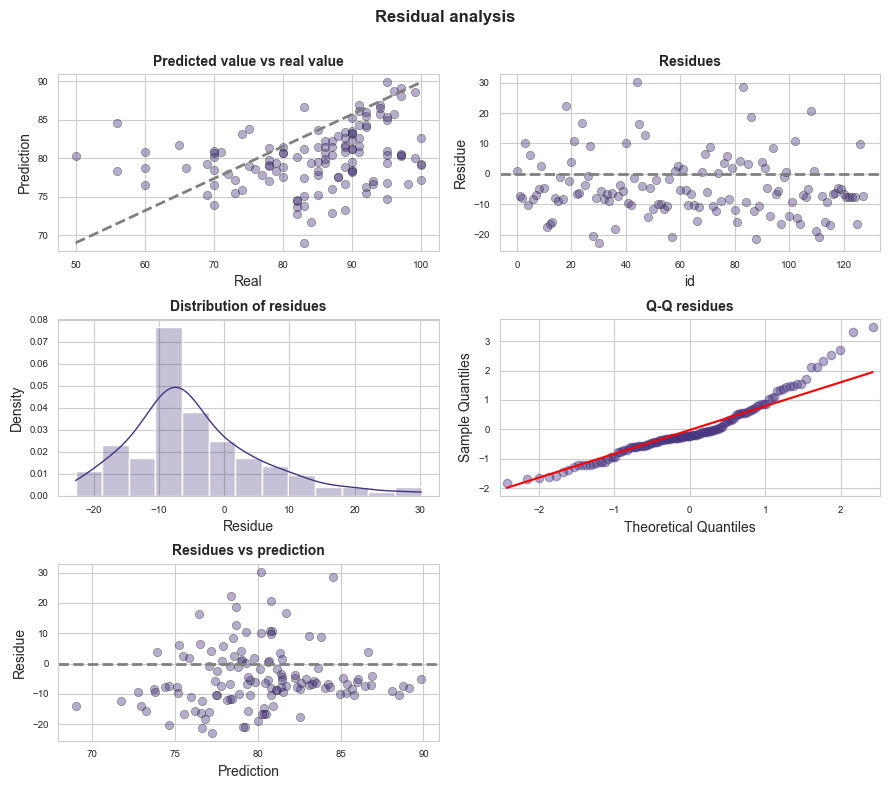

In [50]:
# Graphs
# ==============================================================================
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(9, 8))

# axes[0,0]
sns.scatterplot(
    x          = y_train,
    y          = prediction_train_interaction,
    edgecolors = (0, 0, 0),
    alpha      = 0.4,
    ax         = axes[0, 0]
)

points = [(y_train.min(),prediction_train_interaction.min()), (y_train.max(), prediction_train_interaction.max())]  # x, y coordinates
line_data = pd.DataFrame(points, columns=['x', 'y'])
sns.lineplot(
    x          = 'x',
    y          = 'y',
    data       = line_data, 
    linestyle  = '--', 
    color      = 'gray', 
    lw         = 2,
    ax         = axes[0, 0]
)

axes[0, 0].set_title('Predicted value vs real value', fontsize = 10, fontweight = "bold")
axes[0, 0].set_xlabel('Real')
axes[0, 0].set_ylabel('Prediction')
axes[0, 0].tick_params(labelsize = 7)

# axes[0,1]
sns.scatterplot(
    x          = list(range(len(y_train))),
    y          = residues_train_interaction,
    edgecolors = (0, 0, 0),
    alpha      = 0.4,
    ax         = axes[0, 1]
)

axes[0, 1].axhline(y = 0, linestyle = '--', color = 'gray', lw=2)
axes[0, 1].set_title('Residues', fontsize = 10, fontweight = "bold")
axes[0, 1].set_xlabel('id')
axes[0, 1].set_ylabel('Residue')
axes[0, 1].tick_params(labelsize = 7)

# axes[1, 0]
sns.histplot(
    data    = residues_train_interaction,
    stat    = "density",
    kde     = True,
    line_kws= {'linewidth': 1},
    alpha   = 0.3,
    ax      = axes[1, 0]
)

axes[1, 0].set_title('Distribution of residues', fontsize = 10,
                     fontweight = "bold")
axes[1, 0].set_xlabel("Residue")
axes[1, 0].tick_params(labelsize = 7)

# axes[1, 1]
sm.qqplot(
    residues_train_interaction,
    fit   = True,
    line  = 'q',
    ax    = axes[1, 1], 
    alpha = 0.4,
    lw    = 2
)

axes[1, 1].set_title('Q-Q residues', fontsize = 10, fontweight = "bold")
axes[1, 1].tick_params(labelsize = 7)

# axes[2, 0]
sns.scatterplot(
    x          = prediction_train_interaction, 
    y          = residues_train_interaction,
    edgecolors = (0, 0, 0),
    alpha      = 0.4,
    ax         = axes[2, 0]
)

axes[2, 0].axhline(y = 0, linestyle = '--', color = 'grey', lw=2)
axes[2, 0].set_title('Residues vs prediction', fontsize = 10, fontweight = "bold")
axes[2, 0].set_xlabel('Prediction')
axes[2, 0].set_ylabel('Residue')
axes[2, 0].tick_params(labelsize = 7)

# Eliminate empty axes
fig.delaxes(axes[2,1])

fig.tight_layout()
plt.subplots_adjust(top=0.9)
fig.suptitle('Residual analysis', fontsize = 12, fontweight = "bold");

We observe that the residuals for this model are notably skewed to the left. This lack of symmetry is a degradation compared to the more "normally" distributed residuals of the model without interactions

## Making a prediction

Now, we will use our models (with and without interactions) to predict the rating of a movie that is not in the data frame. To that end, we create a list with all movie titles from our dataset, so that we can verify if our chosen test titles are in said dataset.

In [44]:
titles = movies.index.values.tolist()

In [45]:
'American Fiction' in titles or 'Babylon' in titles or 'Furiosa: A Mad Max Saga' in titles or 'Do the Right Thing' in titles\
or 'Juror #2'.title() in titles or "Uncut Gems".title() in titles

False

Our chosen titles are not in the dataset. Next, we create a dataframe with the necessary information to make a prediction using our model. We will include, besides the `Title` of the movie, their `Revenue_Millions_USD`, `IMDb` rating, and our `Personal` rating.

In [46]:
favorites = pd.DataFrame({'Year':[2023,2022,2024,1989,2024 ], 
                          'Runtime':[117,189,148,120,116],\
                          'Budget':[10,78,168,6.2,30],\
                          'Revenue':[23.026243,64.9,174.3,37.3,20.4],\
                          'Personal':[85,93,97,88,85],\
                          'IMDb':[75,71,75,80,70],\
                          'Rotten_Tomatoes':[93,57,90,92,93],\
                          'Metacritic':[81,61,58,93,72],\
                          'Filmaffinity':[67,69,67,73,68],\
                          'Fans':[74,78,76,88,68]},
                         index=['American Fiction','Babylon',"Furiosa: A Mad Max Saga",'Do the Right Thing','Juror #2'])
favorites

,Year,Runtime,Budget,Revenue,Personal,IMDb,Rotten_Tomatoes,Metacritic,Filmaffinity,Fans
American Fiction,2023,117,10.0,23.026243,85,75,93,81,67,74
Babylon,2022,189,78.0,64.900000,93,71,57,61,69,78
Furiosa: A Mad Max Saga,2024,148,168.0,174.300000,97,75,90,58,67,76
Do the Right Thing,1989,120,6.2,37.300000,88,80,92,93,73,88
Juror #2,2024,116,30.0,20.400000,85,70,93,72,68,68


In [47]:
model.predict(exog = favorites)

American Fiction           79.116857
Babylon                    75.617246
Furiosa: A Mad Max Saga    72.425371
Do the Right Thing         82.426383
Juror #2                   76.423855
dtype: float64

In [48]:
model_interaction.predict(exog = favorites)

American Fiction           77.999927
Babylon                    74.319954
Furiosa: A Mad Max Saga    74.119902
Do the Right Thing         81.357827
Juror #2                   77.015665
dtype: float64

We observe that the predictions generated by the two models are highly consistent, with only low differences for example with 'American Fiction' predicted at $79.11$ vs. $79.57$. Still, the predictions are on the low side, but not that much. Also since the ANOVA F-test (p-value = 0.2046) concluded that the model with interactions does not significantly improve the fit, and the residual analysis showed the simpler model's errors were more normally distributed, we select the model without interactions as the most appropriate and parsimonious choice.We select the model without interactions as the most appropriate choice.

The predictions make sense in the context of the training data but may appear 'low' if the target audience typically rates movies much higher (in this case these were our favorite movies so maybe there has been some "overating"), they fall within the upper-middle range of a 1-100 scale.

## References

Regresión lineal con Python by Joaquín Amat Rodrigo, available under a Attribution 4.0 International (CC BY 4.0) at https://www.cienciadedatos.net/documentos/py10-regresion-lineal-python.html